# DSP 577 Capstone — Global Climate & Health Impact  |  proj_577_I_fixed

**Dataset:** `global_climate_health_impact_tracker_2015_2025.csv`  
**Observations:** 14,100 rows × 30 columns · 25 countries · Weekly 2015–2025  
**Targets:** `mental_health_index` · `respiratory_disease_rate` · `heat_related_admissions`  
**Task:** Multi-output regression — predict all three health outcomes from climate inputs  

**Fixes applied vs proj_577_I:**  
- `year` and `month` removed from features (data leakage)  
- `df_raw` saved before encoding — SHAP per-country lookup uses real country names  
- `make_sequences` rewritten to reset per country — no boundary crossing between countries  
- `make_sequences_with_target_lag` same fix applied  

---

## Table of Contents
1. [Phase 1 — Data Exploration & EDA](#phase1)
2. [Phase 2 — Preprocessing & Feature Engineering](#phase2)
3. [Phase 3 — Model Training & Evaluation](#phase3)
4. [Phase 4 — Model Comparison & Interpretation](#phase4)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, cross_val_score, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor

from tensorflow import keras
from tensorflow.keras import layers

import shap

print('All imports successful.')

All imports successful.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
<a id='phase1'></a>
## Phase 1 — Data Exploration & EDA

In [3]:
df = pd.read_csv('/content/drive/MyDrive/global_climate_health_impact_tracker_2015_2025.csv')
#/content/drive/MyDrive/global_climate_health_impact_tracker_2015_2025.csv
# global_climate_health_impact_tracker_2015_2025.csv
#/content/global_climate_health_impact_tracker_2015_2025.csv
df.head(10)

,record_id,country_code,country_name,region,income_level,date,year,month,week,latitude,...,air_quality_index,respiratory_disease_rate,cardio_mortality_rate,vector_disease_risk_score,waterborne_disease_incidents,heat_related_admissions,healthcare_access_index,gdp_per_capita_usd,mental_health_index,food_security_index
0,1,USA,United States,North America,High,2015-01-04,2015,1,1,37.09,...,82.0,69.4,31.5,6.6,16.2,1.4,77.3,63627.0,71.2,90.2
1,2,USA,United States,North America,High,2015-01-11,2015,1,2,37.09,...,6.0,70.0,26.3,5.2,11.4,0.0,83.6,63627.0,70.6,94.0
2,3,USA,United States,North America,High,2015-01-18,2015,1,3,37.09,...,137.0,66.9,33.4,1.3,19.5,0.0,84.7,63627.0,63.4,100.0
3,4,USA,United States,North America,High,2015-01-25,2015,1,4,37.09,...,-3.0,47.0,35.0,6.0,9.7,9.0,84.3,63627.0,68.1,96.4
4,5,USA,United States,North America,High,2015-02-01,2015,2,5,37.09,...,48.0,61.3,28.3,1.4,22.6,27.3,83.6,63733.0,69.1,100.0
5,6,USA,United States,North America,High,2015-02-08,2015,2,6,37.09,...,157.0,80.2,30.6,0.7,23.7,11.9,78.0,63733.0,70.1,97.1
6,7,USA,United States,North America,High,2015-02-15,2015,2,7,37.09,...,51.0,70.3,33.2,5.9,25.4,9.1,81.7,63733.0,68.5,100.0
7,8,USA,United States,North America,High,2015-02-22,2015,2,8,37.09,...,5.0,48.0,33.3,6.4,17.7,20.3,86.7,63733.0,59.4,95.0
8,9,USA,United States,North America,High,2015-03-01,2015,3,9,37.09,...,29.0,80.3,24.9,5.9,18.3,7.8,84.9,63839.0,75.7,100.0
9,10,USA,United States,North America,High,2015-03-08,2015,3,10,37.09,...,22.0,59.1,32.5,0.3,18.8,13.7,87.1,63839.0,71.9,95.2


In [ ]:
df.dtypes

,0
record_id,int64
country_code,object
country_name,object
region,object
income_level,object
date,object
year,int64
month,int64
week,int64
latitude,float64


In [ ]:
df.isna().sum()

,0
record_id,0
country_code,0
country_name,0
region,0
income_level,0
date,0
year,0
month,0
week,0
latitude,0


In [ ]:
# Check for duplicates
print('Duplicate rows:', df.duplicated().sum())
print('Countries:', df['country_name'].nunique())
print('Regions:', df['region'].unique())
print('Income levels:', df['income_level'].unique())
print('Date range:', df['date'].min(), '->', df['date'].max())
print('Rows per country (first 5):', df.groupby('country_name').size().head().to_dict())

Duplicate rows: 0
Countries: 25
Regions: ['North America' 'South Asia' 'East Asia' 'South America' 'Africa'
 'Europe' 'Oceania' 'Southeast Asia']
Income levels: ['High' 'Lower-Middle' 'Upper-Middle']
Date range: 2015-01-04 -> 2025-10-19
Rows per country (first 5): {'Argentina': 564, 'Australia': 564, 'Bangladesh': 564, 'Brazil': 564, 'Canada': 564}


In [ ]:
df.describe()

,record_id,year,month,week,latitude,longitude,population_millions,temperature_celsius,temp_anomaly_celsius,precipitation_mm,...,air_quality_index,respiratory_disease_rate,cardio_mortality_rate,vector_disease_risk_score,waterborne_disease_incidents,heat_related_admissions,healthcare_access_index,gdp_per_capita_usd,mental_health_index,food_security_index
count,14100.000000,14100.000000,14100.000000,14100.000000,14100.000000,14100.000000,14100.000000,14100.000000,14100.000000,14100.000000,...,14100.000000,14100.000000,14100.000000,14100.000000,14100.000000,14100.000000,14100.000000,14100.000000,14100.000000,14100.000000
mean,7050.500000,2019.911348,6.437943,26.221631,18.905200,27.349600,217.440000,8.607113,0.120879,81.149440,...,98.750071,70.016872,30.758596,12.096277,22.172965,6.880794,64.875674,26331.105887,69.874638,93.295780
std,4070.463733,3.118225,3.421173,14.930110,25.730498,76.062029,355.979373,11.289938,0.506365,40.821462,...,59.143284,15.223261,5.605436,17.146545,6.609017,9.498276,18.230095,26329.114275,5.025983,6.295667
min,1.000000,2015.000000,1.000000,1.000000,-38.410000,-106.340000,26.000000,-20.740000,-1.760000,0.000000,...,-52.000000,21.200000,8.000000,0.000000,0.000000,0.000000,27.900000,1565.000000,47.700000,62.200000
25%,3525.750000,2017.000000,3.000000,13.000000,4.570000,-3.740000,60.000000,0.257500,-0.220000,51.500000,...,54.000000,59.200000,27.000000,3.500000,17.800000,0.000000,47.100000,3548.000000,66.500000,88.800000
50%,7050.500000,2020.000000,6.000000,26.000000,23.630000,22.930000,98.000000,8.630000,0.120000,80.900000,...,93.000000,69.600000,30.800000,5.800000,22.100000,0.600000,66.600000,13941.000000,70.000000,94.400000
75%,10575.250000,2023.000000,9.000000,39.000000,37.090000,100.990000,206.000000,16.850000,0.460000,110.600000,...,142.000000,80.500000,34.500000,8.900000,26.400000,12.300000,81.500000,50206.500000,73.300000,99.700000
max,14100.000000,2025.000000,12.000000,53.000000,56.130000,138.250000,1411.000000,38.330000,2.120000,222.900000,...,302.000000,131.800000,51.100000,100.000000,63.000000,59.600000,102.000000,78630.000000,88.700000,100.000000


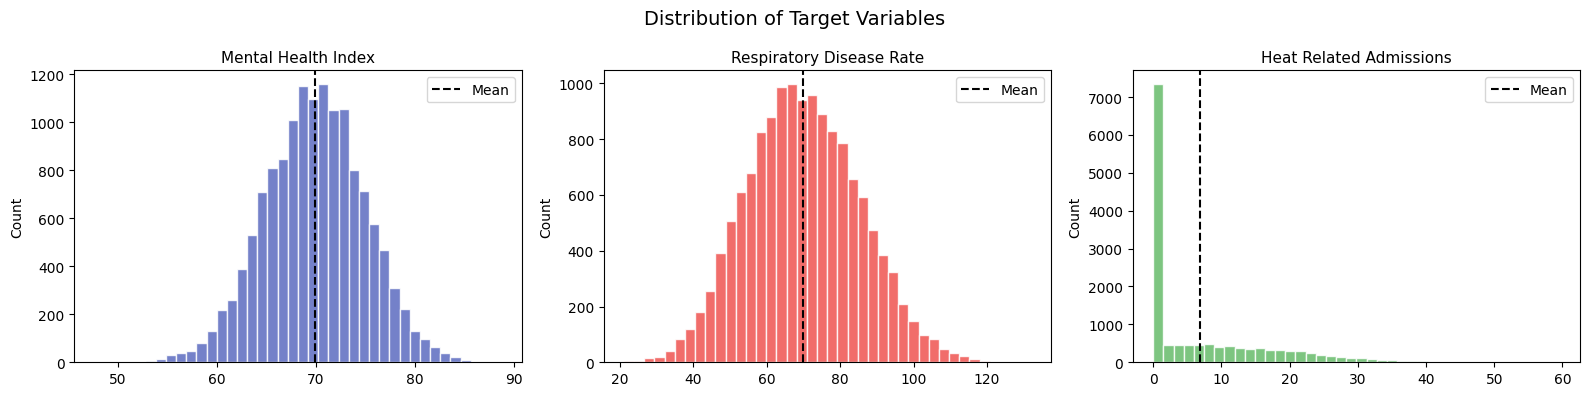

In [4]:
# --- 1.1  Target variable distributions ---
targets = ['mental_health_index', 'respiratory_disease_rate', 'heat_related_admissions']
target_colors = ['#5C6BC0', '#EF5350', '#66BB6A']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col, color in zip(axes, targets, target_colors):
    ax.hist(df[col], bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(), color='black', linestyle='--', label='Mean')
    ax.set_title(col.replace('_', ' ').title(), fontsize=11)
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('Distribution of Target Variables', fontsize=14)
plt.tight_layout()
plt.show()

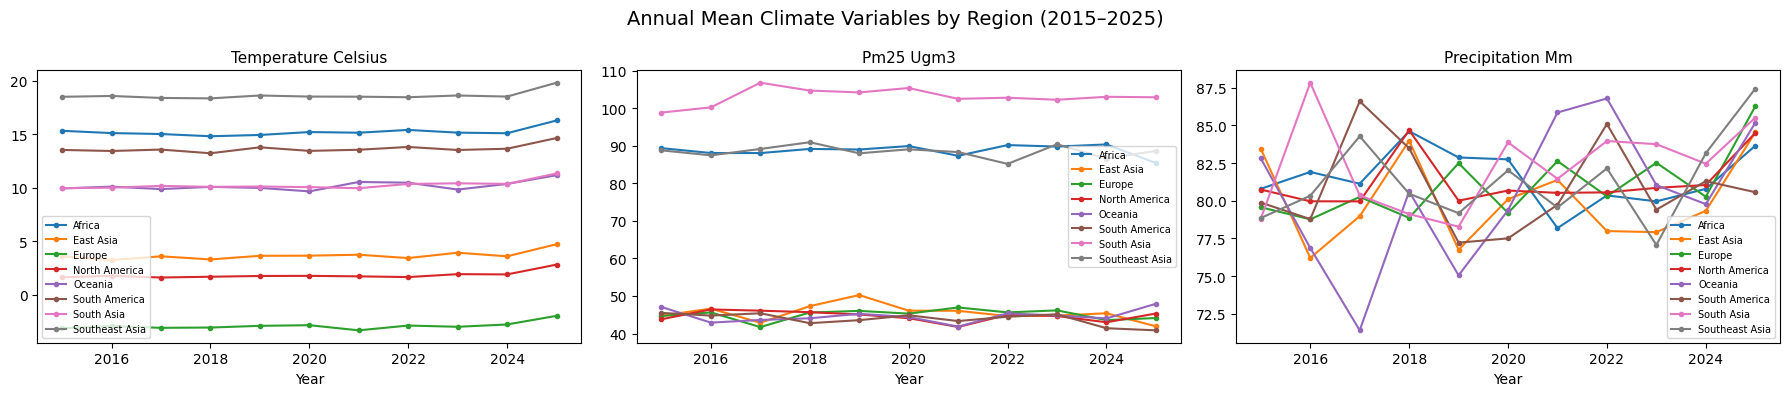

In [ ]:
# --- 1.2  Climate variables over time per region (annual means) ---
df['date'] = pd.to_datetime(df['date'])
climate_vars = ['temperature_celsius', 'pm25_ugm3', 'precipitation_mm']

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, col in zip(axes, climate_vars):
    annual_region = df.groupby(['year', 'region'])[col].mean().reset_index()
    for region in annual_region['region'].unique():
        sub = annual_region[annual_region['region'] == region]
        ax.plot(sub['year'], sub[col], marker='o', markersize=3, label=region)
    ax.set_title(col.replace('_', ' ').title(), fontsize=11)
    ax.set_xlabel('Year')
    ax.legend(fontsize=7, loc='best')

plt.suptitle('Annual Mean Climate Variables by Region (2015–2025)', fontsize=14)
plt.tight_layout()
plt.show()

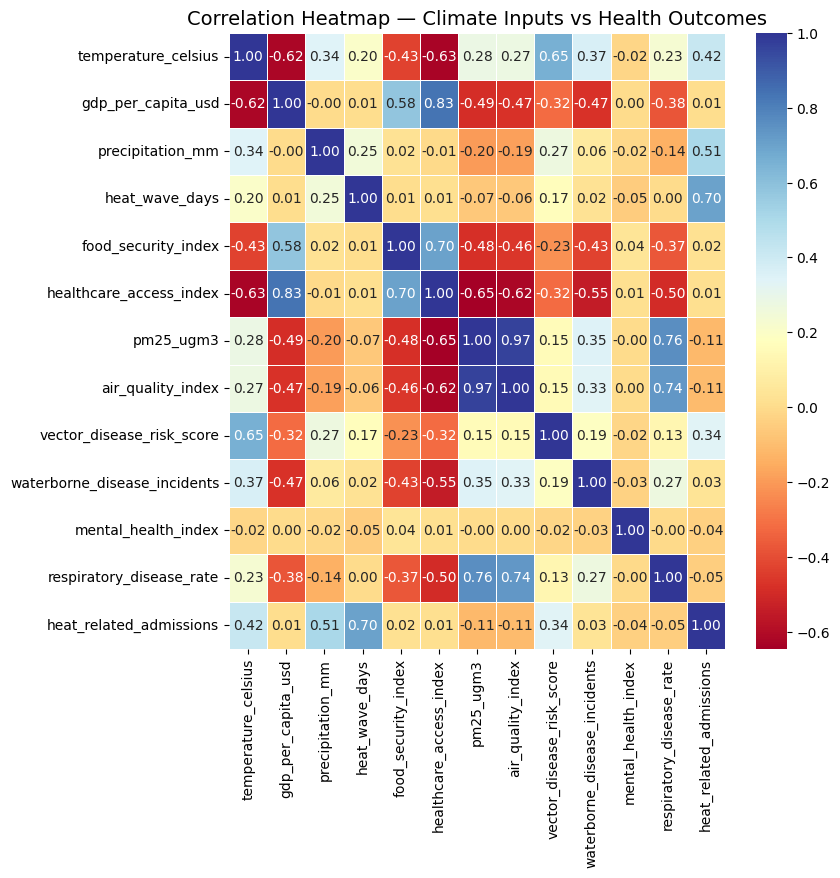

In [ ]:
# --- 1.3  Correlation heatmap (climate inputs vs health outcomes) ---
import seaborn as sns
import matplotlib.pyplot as plt

#Updated
corr_cols = ['temperature_celsius', 'gdp_per_capita_usd', 'precipitation_mm',
             'heat_wave_days', 'food_security_index', 'healthcare_access_index',
             'pm25_ugm3', 'air_quality_index', 'vector_disease_risk_score',
             'waterborne_disease_incidents',
             'mental_health_index', 'respiratory_disease_rate', 'heat_related_admissions']
#flood_indicator, drought_indicator, temp_anomaly_celsius

corr = df[corr_cols].corr()

plt.figure(figsize=(8, 8))
sns.heatmap(corr, annot=True, cmap='RdYlBu', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap — Climate Inputs vs Health Outcomes', fontsize=14)
plt.show()

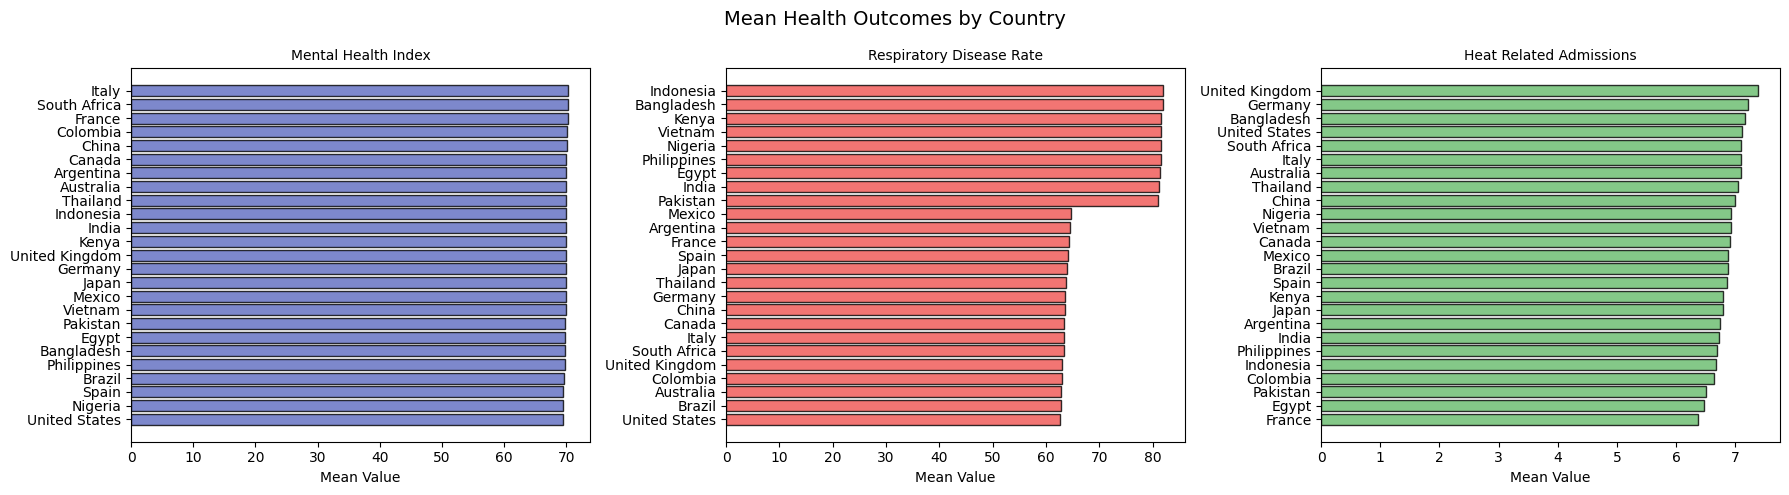

In [ ]:
# --- 1.4  Countries with extreme health outcomes (flag for SHAP comparison) ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, color in zip(axes, targets, target_colors):
    country_mean = df.groupby('country_name')[col].mean().sort_values(ascending=False)
    ax.barh(country_mean.index, country_mean.values, color=color, edgecolor='black', alpha=0.8)
    ax.set_title(col.replace('_', ' ').title(), fontsize=10)
    ax.set_xlabel('Mean Value')
    ax.invert_yaxis()

plt.suptitle('Mean Health Outcomes by Country', fontsize=14)
plt.tight_layout()
plt.show()

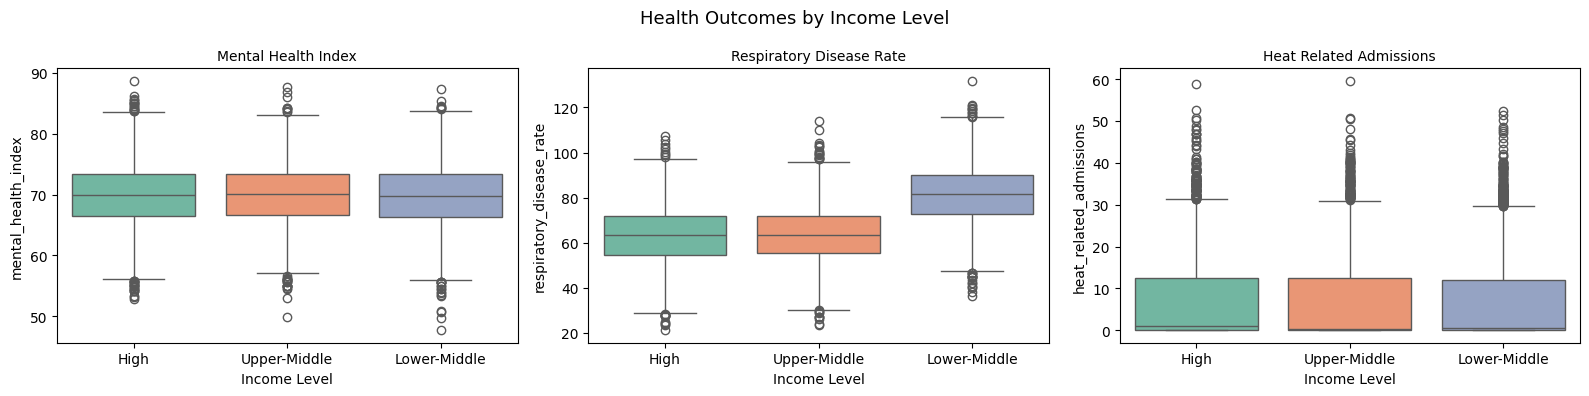

In [ ]:
# --- 1.5  Targets by income level (class imbalance check) ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col, color in zip(axes, targets, target_colors):
    sns.boxplot(data=df, x='income_level', y=col,
                order=['High', 'Upper-Middle', 'Lower-Middle'],
                palette='Set2', ax=ax)
    ax.set_title(col.replace('_', ' ').title(), fontsize=10)
    ax.set_xlabel('Income Level')

plt.suptitle('Health Outcomes by Income Level', fontsize=13)
plt.tight_layout()
plt.show()

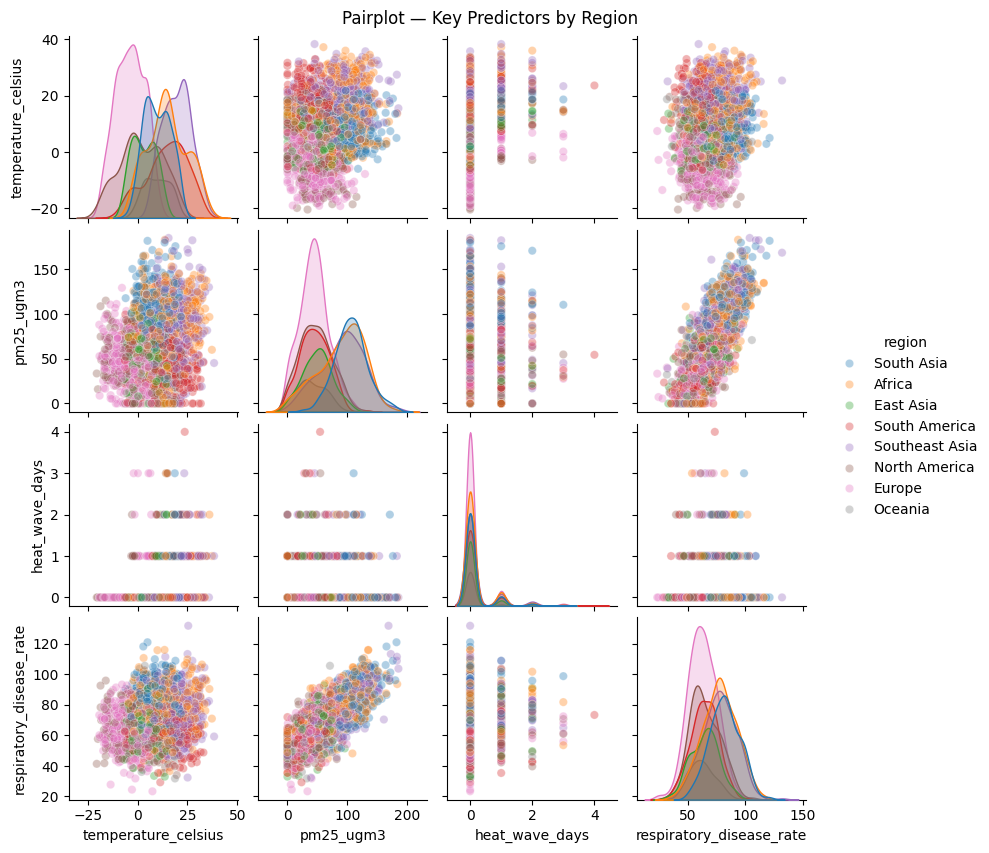

In [ ]:
# --- 1.6  Pairplot: key climate features coloured by region ---
sample = df[['temperature_celsius', 'pm25_ugm3', 'heat_wave_days',
             'respiratory_disease_rate', 'region']].sample(2000, random_state=42)
grid = sns.pairplot(data=sample,
                    vars=['temperature_celsius', 'pm25_ugm3', 'heat_wave_days', 'respiratory_disease_rate'],
                    hue='region', plot_kws={'alpha': 0.35}, height=2.1)
grid.figure.suptitle('Pairplot — Key Predictors by Region', y=1.01)
plt.show()

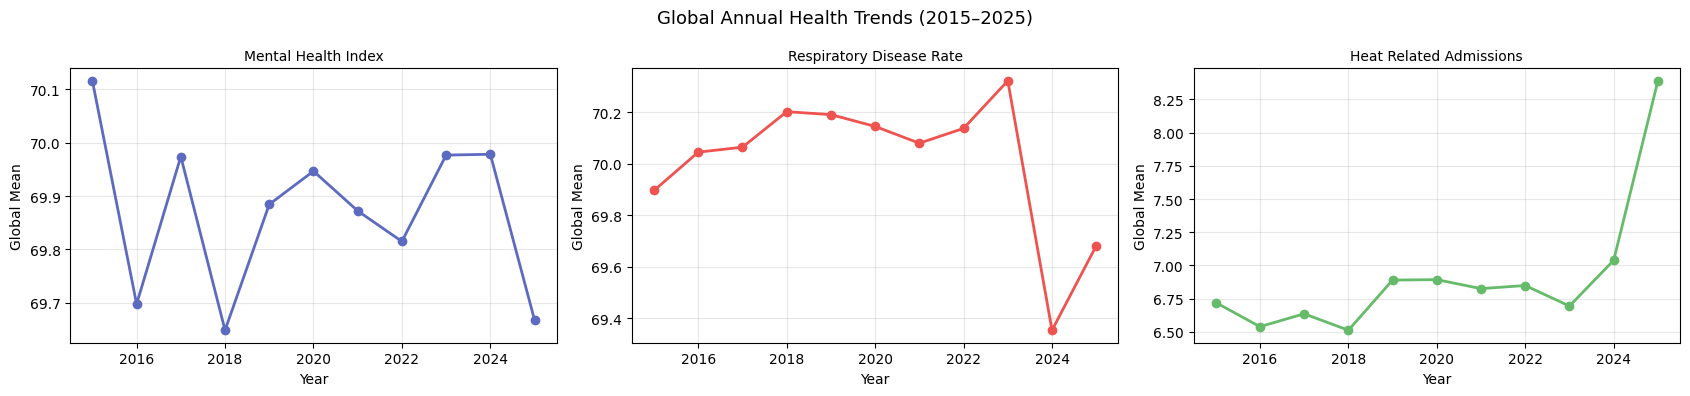

In [ ]:
# --- 1.7  Time series: target trends globally (annual average) ---
annual_global = df.groupby('year')[targets].mean()

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for ax, col, color in zip(axes, targets, target_colors):
    ax.plot(annual_global.index, annual_global[col], color=color, marker='o', linewidth=2)
    ax.set_title(col.replace('_', ' ').title(), fontsize=10)
    ax.set_xlabel('Year')
    ax.set_ylabel('Global Mean')
    ax.grid(True, alpha=0.3)

plt.suptitle('Global Annual Health Trends (2015–2025)', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# --- 1.8  Autocorrelation analysis ---

# Part A: Checking if the health targets remember their past; weekly lag
print("Target autocorrelation at lag-1 (per country):")
df_sorted = df.sort_values(['country_name', 'date'])

for t in targets:
    lagged = df_sorted.groupby('country_name')[t].shift(1)
    r = lagged.corr(df_sorted[t])
    print(f"  {t:35s}: {r:.3f}")

Target autocorrelation at lag-1 (per country):
  mental_health_index                : -0.003
  respiratory_disease_rate           : 0.335
  heat_related_admissions            : 0.632


In [ ]:
# Part B: Can lag climate features improve correlation and predictive power of targets?
climate_cols = [
    'temperature_celsius', 'pm25_ugm3', 'air_quality_index',
    'heat_wave_days', 'extreme_weather_events',
    'precipitation_mm', 'drought_indicator'
]

print("\nBest lag correlation vs raw — climate inputs vs each target:")
for t in targets:
    print(f"\n  {t}:")
    for col in climate_cols:
        raw_r = abs(df_sorted[col].corr(df_sorted[t]))
        best_r, best_lag = raw_r, 0
        for lag in [2, 4, 8, 12]:
            lagged = df_sorted.groupby('country_name')[col].shift(lag)
            lr = abs(lagged.corr(df_sorted[t]))
            if lr > best_r:
                best_r, best_lag = lr, lag
        if best_lag > 0:
            print(f"    {col:30s}: raw={raw_r:.3f} → lag{best_lag}={best_r:.3f}  (+{best_r-raw_r:.3f})")
        else:
            print(f"    {col:30s}: raw={raw_r:.3f}  (no lag improves)")


Best lag correlation vs raw — climate inputs vs each target:

  mental_health_index:
    temperature_celsius           : raw=0.019  (no lag improves)
    pm25_ugm3                     : raw=0.003 → lag8=0.006  (+0.004)
    air_quality_index             : raw=0.001 → lag8=0.009  (+0.008)
    heat_wave_days                : raw=0.053  (no lag improves)
    extreme_weather_events        : raw=0.079  (no lag improves)
    precipitation_mm              : raw=0.016 → lag4=0.017  (+0.002)
    drought_indicator             : raw=0.062  (no lag improves)

  respiratory_disease_rate:
    temperature_celsius           : raw=0.232 → lag12=0.278  (+0.047)
    pm25_ugm3                     : raw=0.759  (no lag improves)
    air_quality_index             : raw=0.736  (no lag improves)
    heat_wave_days                : raw=0.003 → lag4=0.041  (+0.038)
    extreme_weather_events        : raw=0.006 → lag4=0.040  (+0.034)
    precipitation_mm              : raw=0.142  (no lag improves)
    drought_ind

Part A and B will help interprete the LTSM predictions better; shifting climate variables by 2, 4, 8, or 12 weeks adds little to no correlation gain for time series model

---
<a id='phase2'></a>
## Phase 2 — Preprocessing & Feature Engineering

In [5]:
# Sort by country then date — critical before any lag/rolling operation
df = df.sort_values(['country_code', 'date']).reset_index(drop=True)

print('Sorted by country_code + date. Shape:', df.shape)

Sorted by country_code + date. Shape: (14100, 30)


In [6]:
# --- Lag features per country (2, 4, 8, 12 weeks) ---
lag_vars = ['temperature_celsius', 'pm25_ugm3', 'precipitation_mm', 'heat_wave_days']
lag_weeks = [2, 4, 8, 12]

for var in lag_vars:
    for lag in lag_weeks:
        col_name = '{}_lag{}w'.format(var, lag)
        df[col_name] = df.groupby('country_code')[var].shift(lag)

print('Lag features added. New shape:', df.shape)

Lag features added. New shape: (14100, 46)


In [7]:
# --- Rolling window features (4w and 8w means) ---
roll_vars = ['temperature_celsius', 'pm25_ugm3', 'air_quality_index']
roll_windows = [4, 8]

for var in roll_vars:
    for window in roll_windows:
        col_name = '{}_roll{}w'.format(var, window)
        df[col_name] = (df.groupby('country_code')[var]
                          .transform(lambda x: x.rolling(window, min_periods=1).mean()))

print('Rolling features added. New shape:', df.shape)

Rolling features added. New shape: (14100, 52)


In [8]:
# Save a copy of df with country identifiers BEFORE encoding and dropping columns.
# Used later in the SHAP per-country analysis to map test rows back to country names.
df_raw = df[['country_code', 'country_name', 'date', 'year']].copy()
print('df_raw saved. Shape:', df_raw.shape)

df_raw saved. Shape: (14100, 4)


In [ ]:
# --- Encode categorical features ---
#df = pd.get_dummies(df, columns=['region', 'income_level'], drop_first=True)

# Drop identifier / redundant columns
# FIX: 'year' and 'month' removed — both were top SHAP features due to synthetic
# data generation patterns, not genuine climate-health causation (data leakage).
#drop_cols = ['record_id', 'country_name', 'country_code', 'date', 'week', 'year','month'] #'year',
#df.drop(columns=drop_cols, inplace=True)

# Drop rows with NaN introduced by the 12-week lag (first 12 rows per country)
#df.dropna(inplace=True)

#print('After encoding and NaN drop. Shape:', df.shape)
#print('Remaining NaN:', df.isna().sum().sum())

After encoding and NaN drop. Shape: (13800, 53)
Remaining NaN: 0


In [9]:
# --- 1. Cyclic Encoding for Month ---
# This captures seasonality (Dec is near Jan) without linear leakage.
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# --- Time-based train / val / test split  (NO SHUFFLE — strict temporal ordering) ---
# --- 2. Define Split Masks (While 'year' still exists) ---
train_mask = df['year'] <= 2021
val_mask   = (df['year'] >= 2022) & (df['year'] <= 2023)
test_mask  = df['year'] >= 2024

In [10]:
# --- Encode categorical features ---
df = pd.get_dummies(df, columns=['region', 'income_level'], drop_first=True)

# --- 3. Refine Feature Columns ---
# Explicitly exclude the 'leaky' columns but include our new cyclic ones.
# We also drop 'month' because its signal is now in month_sin/cos.
# data generation patterns, not genuine climate-health causation (data leakage).
drop_cols = ['record_id', 'country_name', 'country_code', 'date', 'week', 'year','month'] #'year',
df.drop(columns=drop_cols, inplace=True)

# Drop rows with NaN introduced by the 12-week lag (first 12 rows per country)
df.dropna(inplace=True)

print('After encoding and NaN drop. Shape:', df.shape)
print('Remaining NaN:', df.isna().sum().sum())

After encoding and NaN drop. Shape: (13800, 54)
Remaining NaN: 0


In [11]:
# --- Define features and targets ---
target_cols = ['mental_health_index', 'respiratory_disease_rate', 'heat_related_admissions']
feature_cols = [c for c in df.columns if c not in target_cols]

print('Features ({}):\n'.format(len(feature_cols)), feature_cols)
print('\nTargets:', target_cols)

Features (51):
 ['latitude', 'longitude', 'population_millions', 'temperature_celsius', 'temp_anomaly_celsius', 'precipitation_mm', 'heat_wave_days', 'drought_indicator', 'flood_indicator', 'extreme_weather_events', 'pm25_ugm3', 'air_quality_index', 'cardio_mortality_rate', 'vector_disease_risk_score', 'waterborne_disease_incidents', 'healthcare_access_index', 'gdp_per_capita_usd', 'food_security_index', 'temperature_celsius_lag2w', 'temperature_celsius_lag4w', 'temperature_celsius_lag8w', 'temperature_celsius_lag12w', 'pm25_ugm3_lag2w', 'pm25_ugm3_lag4w', 'pm25_ugm3_lag8w', 'pm25_ugm3_lag12w', 'precipitation_mm_lag2w', 'precipitation_mm_lag4w', 'precipitation_mm_lag8w', 'precipitation_mm_lag12w', 'heat_wave_days_lag2w', 'heat_wave_days_lag4w', 'heat_wave_days_lag8w', 'heat_wave_days_lag12w', 'temperature_celsius_roll4w', 'temperature_celsius_roll8w', 'pm25_ugm3_roll4w', 'pm25_ugm3_roll8w', 'air_quality_index_roll4w', 'air_quality_index_roll8w', 'month_sin', 'month_cos', 'region_East A

In [12]:
X_train_full = df.loc[train_mask, feature_cols].values
y_train_full = df.loc[train_mask, target_cols].values

X_val  = df.loc[val_mask, feature_cols].values
y_val  = df.loc[val_mask, target_cols].values

X_test  = df.loc[test_mask, feature_cols].values
y_test  = df.loc[test_mask, target_cols].values

print('Training set shape:',   X_train_full.shape, y_train_full.shape)
print('Validation set shape:', X_val.shape,        y_val.shape)
print('Test set shape:',       X_test.shape,       y_test.shape)

Training set shape: (8825, 51) (8825, 3)
Validation set shape: (2625, 51) (2625, 3)
Test set shape: (2350, 51) (2350, 3)


In [13]:
sc = StandardScaler()
X_train_full_std = sc.fit_transform(X_train_full)
X_val_std        = sc.transform(X_val)
X_test_std       = sc.transform(X_test)

print('X_train_full_std shape:', X_train_full_std.shape)
print('X_val_std shape:',        X_val_std.shape)
print('X_test_std shape:',       X_test_std.shape)

X_train_full_std shape: (8825, 51)
X_val_std shape: (2625, 51)
X_test_std shape: (2350, 51)


In [14]:
# Helper: print RMSE / MAE / R² per target
def print_metrics(name, y_true, y_pred, target_names=target_cols):
    print('\n{}'.format('='*55))
    print(' {}'.format(name))
    print('{}'.format('='*55))
    for i, tgt in enumerate(target_names):
        rmse = mean_squared_error(y_true[:, i], y_pred[:, i]) ** 0.5
        mae  = mean_absolute_error(y_true[:, i], y_pred[:, i])
        r2   = r2_score(y_true[:, i], y_pred[:, i])
        print('  {:30s}  RMSE={:.3f}  MAE={:.3f}  R²={:.3f}'.format(tgt, rmse, mae, r2))

---
<a id='phase3'></a>
## Phase 3 — Model Training & Evaluation

### 3.1 — Ridge Regression  (Linear Baseline)

In [15]:
ridge = MultiOutputRegressor(Ridge(alpha=1.0))

start = time.time()
ridge.fit(X_train_full_std, y_train_full)
stop  = time.time()

print('Fit time: {:.1f}s'.format(stop - start))
print('Train Score (R²): {:.3f}'.format(ridge.score(X_train_full_std, y_train_full)))
print('Val   Score (R²): {:.3f}'.format(ridge.score(X_val_std, y_val)))
print('Test  Score (R²): {:.3f}'.format(ridge.score(X_test_std, y_test)))

Fit time: 0.0s
Train Score (R²): 0.468
Val   Score (R²): 0.458
Test  Score (R²): 0.459


In [ ]:
ridge_pred_val  = ridge.predict(X_val_std)
ridge_pred_test = ridge.predict(X_test_std)
print_metrics('Ridge Regression — Val  Set', y_val,  ridge_pred_val)
print_metrics('Ridge Regression — Test Set', y_test, ridge_pred_test)


 Ridge Regression — Val  Set
  mental_health_index             RMSE=5.016  MAE=4.001  R²=-0.008
  respiratory_disease_rate        RMSE=9.954  MAE=8.041  R²=0.583
  heat_related_admissions         RMSE=4.266  MAE=3.277  R²=0.798

 Ridge Regression — Test Set
  mental_health_index             RMSE=5.034  MAE=4.024  R²=0.012
  respiratory_disease_rate        RMSE=9.979  MAE=7.954  R²=0.576
  heat_related_admissions         RMSE=4.497  MAE=3.442  R²=0.790


In [ ]:
# GridSearchCV — Ridge alpha
ridge_params = {'estimator__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}
grid_search_ridge = GridSearchCV(MultiOutputRegressor(Ridge()),
                                 param_grid=ridge_params, cv=5,
                                 scoring='r2', n_jobs=-1)
grid_search_ridge.fit(X_train_full_std, y_train_full)
ridge_best = grid_search_ridge.best_estimator_

print(grid_search_ridge.best_params_)
print('Train Score: {:.3f}'.format(ridge_best.score(X_train_full_std, y_train_full)))
print('Val   Score: {:.3f}'.format(ridge_best.score(X_val_std, y_val)))
print('Test  Score: {:.3f}'.format(ridge_best.score(X_test_std, y_test)))

{'estimator__alpha': 100.0}
Train Score: 0.466
Val   Score: 0.456
Test  Score: 0.458


In [ ]:
ridge_best_pred_val  = ridge_best.predict(X_val_std)
ridge_best_pred_test = ridge_best.predict(X_test_std)
print_metrics('Ridge (tuned) — Val  Set', y_val,  ridge_best_pred_val)
print_metrics('Ridge (tuned) — Test Set', y_test, ridge_best_pred_test)


 Ridge (tuned) — Val  Set
  mental_health_index             RMSE=5.014  MAE=3.998  R²=-0.007
  respiratory_disease_rate        RMSE=9.964  MAE=8.043  R²=0.582
  heat_related_admissions         RMSE=4.321  MAE=3.250  R²=0.793

 Ridge (tuned) — Test Set
  mental_health_index             RMSE=5.032  MAE=4.021  R²=0.012
  respiratory_disease_rate        RMSE=9.980  MAE=7.947  R²=0.576
  heat_related_admissions         RMSE=4.553  MAE=3.430  R²=0.785


### 3.2 — Random Forest

In [16]:
rf_model_1 = RandomForestRegressor(n_estimators=200, max_depth=10,
                                    min_samples_leaf=5, oob_score=True,
                                    n_jobs=-1, random_state=42)
start = time.time()
rf_model_1.fit(X_train_full, y_train_full)
stop  = time.time()

print('Fit time: {:.1f}s'.format(stop - start))
print('Train Score {:.3f}'.format(rf_model_1.score(X_train_full, y_train_full)))
print('Val   Score {:.3f}'.format(rf_model_1.score(X_val, y_val)))
print('Test  Score {:.3f}'.format(rf_model_1.score(X_test, y_test)))
print('OOB   Score {:.3f}'.format(rf_model_1.oob_score_))

Fit time: 8.9s
Train Score 0.571
Val   Score 0.449
Test  Score 0.440
OOB   Score 0.446


In [17]:
print_metrics('Random Forest (untuned) — Val  Set', y_val,  rf_model_1.predict(X_val))
print_metrics('Random Forest (untuned) — Test Set', y_test, rf_model_1.predict(X_test))


 Random Forest (untuned) — Val  Set
  mental_health_index             RMSE=5.000  MAE=3.981  R²=-0.002
  respiratory_disease_rate        RMSE=10.138  MAE=8.192  R²=0.568
  heat_related_admissions         RMSE=4.448  MAE=2.855  R²=0.780

 Random Forest (untuned) — Test Set
  mental_health_index             RMSE=5.065  MAE=4.051  R²=-0.001
  respiratory_disease_rate        RMSE=10.158  MAE=8.092  R²=0.560
  heat_related_admissions         RMSE=4.789  MAE=3.230  R²=0.762


In [ ]:
# GridSearchCV — Random Forest
rf = RandomForestRegressor(min_samples_leaf=5, oob_score=True, n_jobs=-1, random_state=42)
params = {
    'max_depth':         [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'n_estimators':      [100, 200]
}
grid_search_rf = GridSearchCV(rf, param_grid=params, cv=TimeSeriesSplit(n_splits=5),
                               scoring='r2', n_jobs=-1)
start = time.time()
grid_search_rf.fit(X_train_full, y_train_full)
stop  = time.time()

rf_best = grid_search_rf.best_estimator_

print(grid_search_rf.best_params_)
print('Fit time: {:.1f}s'.format(stop - start))
print('Train Score: {:.3f}'.format(rf_best.score(X_train_full, y_train_full)))
print('Val   Score: {:.3f}'.format(rf_best.score(X_val, y_val)))
print('Test  Score: {:.3f}'.format(rf_best.score(X_test, y_test)))

{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Fit time: 223.0s
Train Score: 0.571
Val   Score: 0.449
Test  Score: 0.440


In [ ]:
print_metrics('Random Forest (tuned) — Val  Set', y_val,  rf_best.predict(X_val))
print_metrics('Random Forest (tuned) — Test Set', y_test, rf_best.predict(X_test))


 Random Forest (tuned) — Val  Set
  mental_health_index             RMSE=5.000  MAE=3.981  R²=-0.002
  respiratory_disease_rate        RMSE=10.138  MAE=8.192  R²=0.568
  heat_related_admissions         RMSE=4.448  MAE=2.855  R²=0.780

 Random Forest (tuned) — Test Set
  mental_health_index             RMSE=5.065  MAE=4.051  R²=-0.001
  respiratory_disease_rate        RMSE=10.158  MAE=8.092  R²=0.560
  heat_related_admissions         RMSE=4.789  MAE=3.230  R²=0.762


### 3.3 — XGBoost

In [19]:
# Multi-output wrapper — one XGBoost per target
xgb_model_1 = MultiOutputRegressor(
    XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.1,
                 subsample=0.8, n_jobs=-1, random_state=42, verbosity=0)
)
start = time.time()
xgb_model_1.fit(X_train_full, y_train_full)
stop  = time.time()

print('Fit time: {:.1f}s'.format(stop - start))
print('Train Score {:.3f}'.format(xgb_model_1.score(X_train_full, y_train_full)))
print('Val   Score {:.3f}'.format(xgb_model_1.score(X_val, y_val)))
print('Test  Score {:.3f}'.format(xgb_model_1.score(X_test, y_test)))

Fit time: 2.0s
Train Score 0.738
Val   Score 0.453
Test  Score 0.447


In [20]:
print_metrics('XGBoost (untuned) — Val  Set', y_val,  xgb_model_1.predict(X_val))
print_metrics('XGBoost (untuned) — Test Set', y_test, xgb_model_1.predict(X_test))


 XGBoost (untuned) — Val  Set
  mental_health_index             RMSE=5.099  MAE=4.087  R²=-0.042
  respiratory_disease_rate        RMSE=10.236  MAE=8.297  R²=0.559
  heat_related_admissions         RMSE=3.776  MAE=2.430  R²=0.842

 XGBoost (untuned) — Test Set
  mental_health_index             RMSE=5.155  MAE=4.137  R²=-0.036
  respiratory_disease_rate        RMSE=10.233  MAE=8.151  R²=0.554
  heat_related_admissions         RMSE=4.123  MAE=2.685  R²=0.823


In [21]:
# GridSearchCV — XGBoost
xgb_params = {
    'estimator__n_estimators':  [100, 200],
    'estimator__max_depth':     [3, 5, 7],
    'estimator__learning_rate': [0.05, 0.1, 0.2],
    'estimator__subsample':     [0.8, 1.0]
}
xgb_base = MultiOutputRegressor(
    XGBRegressor(n_jobs=-1, random_state=42, verbosity=0)
)
grid_search_xgb = GridSearchCV(xgb_base, param_grid=xgb_params,
                                cv=TimeSeriesSplit(n_splits=5),
                                scoring='r2', n_jobs=-1)
start = time.time()
grid_search_xgb.fit(X_train_full, y_train_full)
stop  = time.time()

fit_times = grid_search_xgb.cv_results_['mean_fit_time']
print('Fit times for each parameter combination:')
for i, pms in enumerate(grid_search_xgb.cv_results_['params']):
    print('Params: {}, Fit Time: {:.4f}s'.format(pms, fit_times[i]))

xgb_best = grid_search_xgb.best_estimator_
print('\nBest params:', grid_search_xgb.best_params_)
print('Fit time: {:.1f}s'.format(stop - start))
print('Train Score: {:.3f}'.format(xgb_best.score(X_train_full, y_train_full)))
print('Val   Score: {:.3f}'.format(xgb_best.score(X_val, y_val)))
print('Test  Score: {:.3f}'.format(xgb_best.score(X_test, y_test)))

Fit times for each parameter combination:
Params: {'estimator__learning_rate': 0.05, 'estimator__max_depth': 3, 'estimator__n_estimators': 100, 'estimator__subsample': 0.8}, Fit Time: 1.4439s
Params: {'estimator__learning_rate': 0.05, 'estimator__max_depth': 3, 'estimator__n_estimators': 100, 'estimator__subsample': 1.0}, Fit Time: 1.4090s
Params: {'estimator__learning_rate': 0.05, 'estimator__max_depth': 3, 'estimator__n_estimators': 200, 'estimator__subsample': 0.8}, Fit Time: 2.4101s
Params: {'estimator__learning_rate': 0.05, 'estimator__max_depth': 3, 'estimator__n_estimators': 200, 'estimator__subsample': 1.0}, Fit Time: 2.2285s
Params: {'estimator__learning_rate': 0.05, 'estimator__max_depth': 5, 'estimator__n_estimators': 100, 'estimator__subsample': 0.8}, Fit Time: 3.2486s
Params: {'estimator__learning_rate': 0.05, 'estimator__max_depth': 5, 'estimator__n_estimators': 100, 'estimator__subsample': 1.0}, Fit Time: 3.2360s
Params: {'estimator__learning_rate': 0.05, 'estimator__max

In [22]:
print_metrics('XGBoost (tuned) — Val  Set', y_val,  xgb_best.predict(X_val))
print_metrics('XGBoost (tuned) — Test Set', y_test, xgb_best.predict(X_test))


 XGBoost (tuned) — Val  Set
  mental_health_index             RMSE=4.996  MAE=3.981  R²=-0.000
  respiratory_disease_rate        RMSE=10.004  MAE=8.068  R²=0.579
  heat_related_admissions         RMSE=4.174  MAE=2.669  R²=0.806

 XGBoost (tuned) — Test Set
  mental_health_index             RMSE=5.027  MAE=4.016  R²=0.015
  respiratory_disease_rate        RMSE=9.995  MAE=7.973  R²=0.574
  heat_related_admissions         RMSE=4.467  MAE=2.969  R²=0.793


### Results for XGBoost tuned and Untuned
- respiratory_disease_rate (Validation):       RMSE=10.180, MAE=8.226, R²=0.564
- heat_related_admissions (Validation):       RMSE=3.830, MAE=2.465, R²=0.837
- respiratory_disease_rate (Test):      RMSE=10.280, MAE=8.203, R²=0.550
- heat_related_admissions (Test):    RMSE=4.124, MAE=2.701, R²=0.823

### 3.4 — LSTM  *(sequence length = 26 weeks)*

- The sliding window efffect produces ~12,800 total sequences across all 25 countries
- This LSTM uses only climate features (climate lags) as input

In [ ]:
# Reshape flat feature arrays into (samples, timesteps=26, features)
SEQ_LEN    = 26
N_FEATURES = X_train_full_std.shape[1]
N_TARGETS  = len(target_cols)

# FIX: original make_sequences slid a window across the full array without
# resetting between countries — the last 26 rows of one country bled into
# the first rows of the next, creating nonsense cross-country sequences.
# Solution: build sequences per country then concatenate.
#
# country_ids must align with the split arrays (same sort order as df after
# sort_values(['country_code','date']). We reconstruct it from df before encoding.

def make_sequences_per_country(X, y, country_ids, seq_len=SEQ_LEN):
    """Build sliding-window sequences independently per country.
    Resets the window at each country boundary — no cross-country contamination.
    """
    Xs, ys = [], []
    for cid in np.unique(country_ids):
        mask  = country_ids == cid
        X_c   = X[mask]
        y_c   = y[mask]
        for i in range(seq_len, len(X_c)):
            Xs.append(X_c[i - seq_len:i])
            ys.append(y_c[i])
    return np.array(Xs), np.array(ys)

# Reconstruct country_id arrays aligned to each split
# df was sorted by country_code before splitting — use df_raw to recover codes
df_raw_clean = df_raw.dropna()   # match the dropna() applied to df

# This ensures that any rows dropped (like the 12-week lags) are also dropped from the IDs
train_country_ids = df_raw.loc[df.loc[train_mask].index, 'country_code'].values
val_country_ids   = df_raw.loc[df.loc[val_mask].index,   'country_code'].values
test_country_ids  = df_raw.loc[df.loc[test_mask].index,  'country_code'].values

X_train_seq, y_train_seq = make_sequences_per_country(
    X_train_full_std, y_train_full, train_country_ids)
X_val_seq,   y_val_seq   = make_sequences_per_country(
    X_val_std,        y_val,        val_country_ids)
X_test_seq,  y_test_seq  = make_sequences_per_country(
    X_test_std,       y_test,       test_country_ids)

print('X_train_seq shape:', X_train_seq.shape, '| y_train_seq shape:', y_train_seq.shape)
print('X_val_seq   shape:', X_val_seq.shape)
print('X_test_seq  shape:', X_test_seq.shape)

X_train_seq shape: (8175, 26, 51) | y_train_seq shape: (8175, 3)
X_val_seq   shape: (1975, 26, 51)
X_test_seq  shape: (1700, 26, 51)


In [ ]:
lstm_model = keras.models.Sequential(
    [
        layers.LSTM(64, input_shape=(SEQ_LEN, N_FEATURES), return_sequences=True),
        layers.Dropout(0.2),
        layers.LSTM(32, return_sequences=False),
        layers.Dropout(0.2),
        layers.Dense(16, activation='relu'),
        layers.Dense(N_TARGETS)        # 3 output neurons — one per target
    ]
)

lstm_model.compile(
    loss='mse',
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    metrics=['mae']
)

lstm_model.summary()

lstm_model.fit(X_train_seq, y_train_seq,
               epochs=30, batch_size=128,
               validation_data=(X_val_seq, y_val_seq),
               verbose=True)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 26, 64)         │        29,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 26, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,691 (166.76 KB)

 Trainable params: 42,691 (166.76 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - loss: 3027.1060 - mae: 46.1620 - val_loss: 2550.8682 - val_mae: 41.8724
Epoch 2/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 1954.3899 - mae: 37.0658 - val_loss: 1316.1938 - val_mae: 30.8004
Epoch 3/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 793.9161 - mae: 23.4185 - val_loss: 387.3390 - val_mae: 16.3437
Epoch 4/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 243.1074 - mae: 12.4346 - val_loss: 136.7183 - val_mae: 9.1410
Epoch 5/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 144.3064 - mae: 9.1886 - val_loss: 112.7381 - val_mae: 7.9058
Epoch 6/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 138.2422 - mae: 8.9598 - val_loss: 111.5704 - val_mae: 7.8362
Epoch 7/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 138.1320 - mae: 8.9734 - val_loss: 111.2490 - val_mae: 7.7841
Epoch 8/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 138.6205 - mae: 8.9702 - val_loss: 111.7835 - val_mae: 7.8712
Epoch 9/30
64/64 ━━━━

In [ ]:
loss_val  = lstm_model.evaluate(X_val_seq,  y_val_seq,  batch_size=128, verbose=0)
loss_test = lstm_model.evaluate(X_test_seq, y_test_seq, batch_size=128)
print('Val  MSE: {:.4f}  |  Val  MAE: {:.4f}'.format(loss_val[0],  loss_val[1]))
print('Test MSE: {:.4f}  |  Test MAE: {:.4f}'.format(loss_test[0], loss_test[1]))

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 85.0451 - mae: 7.0318
Val  MSE: 84.6840  |  Val  MAE: 6.9475
Test MSE: 85.0451  |  Test MAE: 7.0318


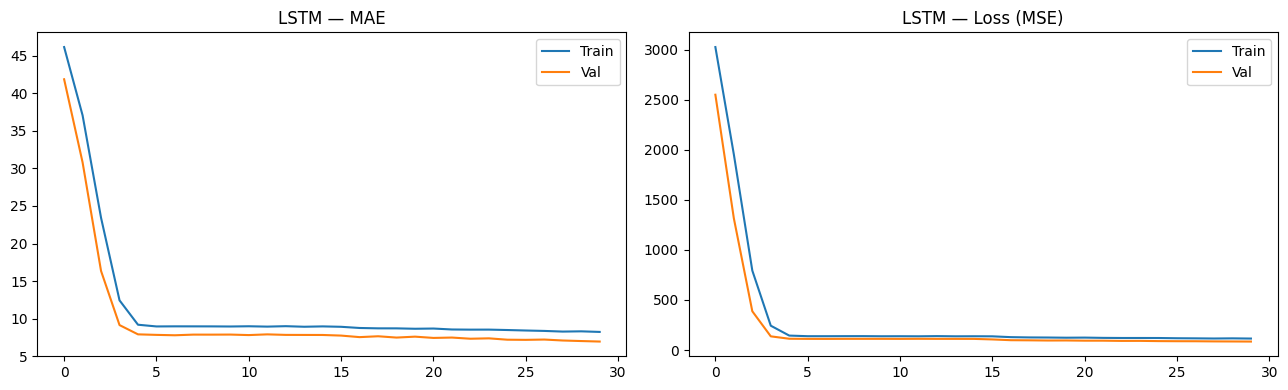

In [ ]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(lstm_model.history.history['mae'],     label='Train')
axes[0].plot(lstm_model.history.history['val_mae'], label='Val')
axes[0].set_title('LSTM — MAE'); axes[0].legend()

axes[1].plot(lstm_model.history.history['loss'],     label='Train')
axes[1].plot(lstm_model.history.history['val_loss'], label='Val')
axes[1].set_title('LSTM — Loss (MSE)'); axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
lstm_pred_val  = lstm_model.predict(X_val_seq)
lstm_pred_test = lstm_model.predict(X_test_seq)
print_metrics('LSTM — Val  Set', y_val_seq,  lstm_pred_val)
print_metrics('LSTM — Test Set', y_test_seq, lstm_pred_test)

62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

 LSTM — Val  Set
  mental_health_index             RMSE=5.619  MAE=4.482  R²=-0.240
  respiratory_disease_rate        RMSE=12.896  MAE=10.350  R²=0.301
  heat_related_admissions         RMSE=7.495  MAE=6.010  R²=0.159

 LSTM — Test Set
  mental_health_index             RMSE=5.730  MAE=4.636  R²=-0.277
  respiratory_disease_rate        RMSE=12.600  MAE=10.082  R²=0.329
  heat_related_admissions         RMSE=7.971  MAE=6.378  R²=0.174


### 3.5 — LSTM 2  *(sequence length = 26 weeks)*

This Model includes target lags for previous timestep's health outcome as additional inputs feature alongside the climate sequence. The climate signal remains
the primary driver for the time model, the lagged target just gives the model context on
the current health state of each country.

In [ ]:
SEQ_LEN   = 26
N_TARGETS = len(target_cols)

# FIX: same per-country boundary fix applied to target-lag variant.
def make_sequences_with_target_lag(X, y, country_ids, seq_len=SEQ_LEN):
    """Per-country sliding window with lagged target appended as extra input.
    Resets at each country boundary — no cross-country contamination.
    """
    Xs, ys = [], []
    for cid in np.unique(country_ids):
        mask  = country_ids == cid
        X_c   = X[mask]
        y_c   = (y[mask].to_numpy() if hasattr(y[mask], 'to_numpy')
                 else np.array(y[mask]))
        for i in range(seq_len + 1, len(X_c)):
            climate_seq    = X_c[i - seq_len:i]          # (seq_len, n_features)
            target_lag_seq = y_c[i - seq_len - 1:i - 1]  # (seq_len, n_targets)
            combined = np.hstack([climate_seq, target_lag_seq])
            Xs.append(combined)
            ys.append(y_c[i])
    return np.array(Xs), np.array(ys)

X_train_seq2, y_train_seq2 = make_sequences_with_target_lag(
    X_train_full_std, y_train_full, train_country_ids)
X_val_seq2,   y_val_seq2   = make_sequences_with_target_lag(
    X_val_std,        y_val,        val_country_ids)
X_test_seq2,  y_test_seq2  = make_sequences_with_target_lag(
    X_test_std,       y_test,       test_country_ids)

N_FEATURES_TAG = X_train_seq2.shape[2]

print(f'Train sequences : {X_train_seq2.shape}')
print(f'Val   sequences : {X_val_seq2.shape}')
print(f'Test  sequences : {X_test_seq2.shape}')
print(f'Input width     : {N_FEATURES_TAG} '
      f'({N_FEATURES_TAG - N_TARGETS} climate + {N_TARGETS} lagged targets)')

Train sequences : (8150, 26, 54)
Val   sequences : (1950, 26, 54)
Test  sequences : (1675, 26, 54)
Input width     : 54 (51 climate + 3 lagged targets)


In [ ]:
# ── Build and train the model ───
lstm_model2 = keras.Sequential([
    layers.LSTM(64, input_shape=(SEQ_LEN, N_FEATURES_TAG),
                return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(32, return_sequences=False),
    layers.Dropout(0.2),
    layers.Dense(N_TARGETS),
])

lstm_model2.compile(
    loss='mse',
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    metrics=['mae']
)
lstm_model2.summary()

history2 = lstm_model2.fit(
    X_train_seq2, y_train_seq2,
    validation_data=(X_val_seq2, y_val_seq2),
    epochs=50,
    batch_size=64,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=8, restore_best_weights=True
        )
    ],
    verbose=1,
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 26, 64)         │        30,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 26, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,979 (167.89 KB)

 Trainable params: 42,979 (167.89 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - loss: 2939.9062 - mae: 45.5005 - val_loss: 2672.9089 - val_mae: 43.1943
Epoch 2/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 2469.6135 - mae: 41.9412 - val_loss: 2308.4224 - val_mae: 40.4854
Epoch 3/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 2134.8560 - mae: 39.1507 - val_loss: 2003.0082 - val_mae: 37.8303
Epoch 4/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 1851.5221 - mae: 36.5135 - val_loss: 1735.9285 - val_mae: 35.2488
Epoch 5/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 1601.9757 - mae: 33.9680 - val_loss: 1500.1643 - val_mae: 32.7699
Epoch 6/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 1381.6370 - mae: 31.5245 - val_loss: 1292.3416 - val_mae: 30.4154
Epoch 7/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 1190.6960 - mae: 29.2526 - val_loss: 1109.4362 - val_mae: 28.1455
Epoch 8/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 1024.4856 - mae: 27.0699 - val_loss: 949.0847 - va

In [ ]:
# ── Evaluate and compare against original LSTM ───
lstm2_pred_val  = lstm_model2.predict(X_val_seq2)
lstm2_pred_test = lstm_model2.predict(X_test_seq2)

print_metrics("LSTM (target lag) — Val  Set", y_val_seq2,  lstm2_pred_val)
print_metrics("LSTM (target lag) — Test Set", y_test_seq2, lstm2_pred_test)

61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

 LSTM (target lag) — Val  Set
  mental_health_index             RMSE=5.089  MAE=4.068  R²=-0.016
  respiratory_disease_rate        RMSE=15.445  MAE=12.417  R²=-0.005
  heat_related_admissions         RMSE=8.345  MAE=6.901  R²=-0.032

 LSTM (target lag) — Test Set
  mental_health_index             RMSE=5.096  MAE=4.097  R²=-0.011
  respiratory_disease_rate        RMSE=15.435  MAE=12.444  R²=-0.002
  heat_related_admissions         RMSE=8.849  MAE=7.271  R²=-0.007


---
<a id='phase4'></a>
## Phase 4 — Model Comparison & Interpretation

In [ ]:
# evaluate_model — TimeSeriesSplit (no shuffle, time-aware)
def evaluate_model(model, X, y):
    cv     = TimeSeriesSplit(n_splits=5)
    scores = cross_val_score(model, X, y, cv=cv, n_jobs=-1,
                             scoring='r2', error_score='raise')
    return scores

In [ ]:
# Register tabular models (LSTM excluded — Keras not compatible with cross_val_score)
models = {
    'Ridge (tuned)':  ridge_best,
    'RF (untuned)':   rf_model_1,
    'RF (tuned)':     rf_best,
    'XGB (untuned)':  xgb_model_1,
    'XGB (tuned)':    xgb_best
}

results, names = list(), list()
for name, model in models.items():
    scores = evaluate_model(model, X_train_full, y_train_full)
    results.append(scores)
    names.append(name)
    print('>%s %.3f (%.3f)' % (name, np.mean(scores), np.std(scores)))

>Ridge (tuned) -3.228 (7.323)
>RF (untuned) 0.417 (0.027)
>RF (tuned) 0.417 (0.027)
>XGB (untuned) 0.393 (0.049)
>XGB (tuned) 0.435 (0.029)


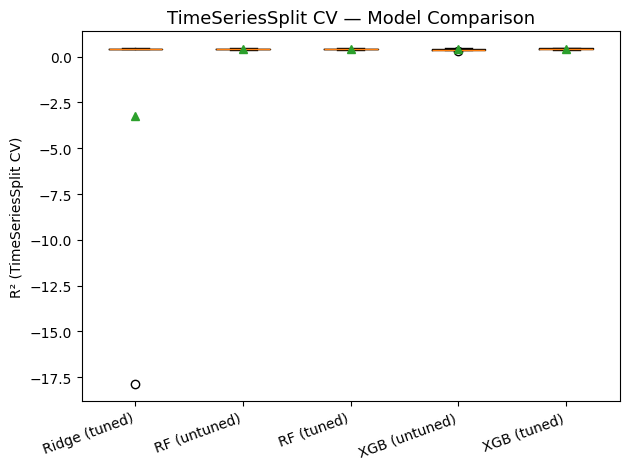

In [ ]:
# Boxplot comparison — matching template style
plt.boxplot(results, labels=names, showmeans=True)
plt.xticks(rotation=20, ha='right')
plt.ylabel('R² (TimeSeriesSplit CV)')
plt.title('TimeSeriesSplit CV — Model Comparison', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Full comparison table — Val and Test sets, all models including LSTM
rows = []

val_preds = {
    'Ridge (tuned)': (ridge_best.predict(X_val_std),  y_val),
    'RF (tuned)':    (rf_best.predict(X_val),          y_val),
    'XGB (tuned)':   (xgb_best.predict(X_val),         y_val),
    'LSTM':          (lstm_model.predict(X_val_seq),    y_val_seq)
}
test_preds = {
    'Ridge (tuned)': (ridge_best.predict(X_test_std), y_test),
    'RF (tuned)':    (rf_best.predict(X_test),         y_test),
    'XGB (tuned)':   (xgb_best.predict(X_test),        y_test),
    'LSTM':          (lstm_model.predict(X_test_seq),   y_test_seq)
}

for mname in val_preds:
    for split, preds_true in [('Val', val_preds[mname]), ('Test', test_preds[mname])]:
        preds, y_true = preds_true
        for i, tgt in enumerate(target_cols):
            rmse = mean_squared_error(y_true[:, i], preds[:, i]) ** 0.5
            mae  = mean_absolute_error(y_true[:, i], preds[:, i])
            r2   = r2_score(y_true[:, i], preds[:, i])
            rows.append({'Model': mname, 'Split': split, 'Target': tgt,
                         'RMSE': round(rmse, 4),
                         'MAE':  round(mae,  4),
                         'R²':   round(r2,   4)})

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))

82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
        Model Split                   Target    RMSE     MAE      R²
Ridge (tuned)   Val      mental_health_index  5.0145  3.9965 -0.0076
Ridge (tuned)   Val respiratory_disease_rate  9.9561  8.0347  0.5829
Ridge (tuned)   Val  heat_related_admissions  4.6075  3.3628  0.7642
Ridge (tuned)  Test      mental_health_index  5.0324  4.0179  0.0124
Ridge (tuned)  Test respiratory_disease_rate  9.9858  7.9520  0.5750
Ridge (tuned)  Test  heat_related_admissions  4.8418  3.5909  0.7564
   RF (tuned)   Val      mental_health_index  5.0017  3.9836 -0.0024
   RF (tuned)   Val respiratory_disease_rate 10.1241  8.1762  0.5687
   RF (tuned)   Val  heat_related_admissions  4.4849  2.8756  0.7765
   RF (tuned)  Test      mental_health_index  5.0674  4.0542 -0.0014
   RF (tuned)  Test respiratory_disease_rate 10.1560  8.0895  0.5604
   RF (tuned)  Test  heat_related_admissions  4.7913  3.2323  0.7615
  XGB (tuned)   Val      

## LSTM model comparison — interpretation

The target-lag LSTM did not improve on the original across the primary
targets. This is related with the dataset size constraint (~512 sequences per country). Adding lagged target features
increases input dimensionality, which requires more training data to
generalise; a condition this dataset does not meet.

The original LSTM is therefore retained as the sequence model. XGBoost
remains the best-performing model overall and the primary basis for
SHAP interpretation and dashboard outputs.

---
### Save Trained Models — Export `.pkl` files for Docker / Streamlit

Trains single-output versions of Ridge, RF, and XGBoost using the best hyperparameters  
found by `GridSearchCV`, then saves all 9 models and 3 scalers to `models/`.  
Commit the `models/` folder to GitHub — Docker bakes them into the image via `COPY . .`  
so `app.py` loads them instantly on cold start with no retraining.

In [ ]:
import os
import joblib
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

MODELS_DIR = 'models'
os.makedirs(MODELS_DIR, exist_ok=True)

# ── Naming helpers — must match app.py exactly ────────────────────────────────
def model_path(target, model_name):
    safe = model_name.lower().replace(' ', '_')
    tgt  = target.split('_')[0]
    return os.path.join(MODELS_DIR, f'{safe}__{tgt}.pkl')

def scaler_path(target):
    return os.path.join(MODELS_DIR, f'scaler__{target}.pkl')

# ── Save scaler — sc was fit on X_train_full, same features for all targets ──
for target in target_cols:
    joblib.dump(sc, scaler_path(target))
    print(f'Scaler saved  → {scaler_path(target)}')

# ── Pull best hyperparameters from GridSearchCV ───────────────────────────────
best_alpha      = grid_search_ridge.best_params_['estimator__alpha']
best_rf_params  = grid_search_rf.best_params_
best_xgb_params = {k.replace('estimator__', ''): v
                   for k, v in grid_search_xgb.best_params_.items()}

print(f'\nBest Ridge alpha : {best_alpha}')
print(f'Best RF params   : {best_rf_params}')
print(f'Best XGB params  : {best_xgb_params}\n')

# ── Train one model per target per algorithm and save ─────────────────────────
# Ridge uses standardised features; RF and XGBoost use raw — matching app.py
for i, target in enumerate(target_cols):
    y_i = y_train_full[:, i]    # single-output slice

    # Ridge Regression
    ridge_s = Ridge(alpha=best_alpha)
    ridge_s.fit(X_train_full_std, y_i)
    joblib.dump(ridge_s, model_path(target, 'Ridge Regression'))

    # Random Forest
    rf_s = RandomForestRegressor(min_samples_leaf=5, n_jobs=-1,
                                  random_state=42, **best_rf_params)
    rf_s.fit(X_train_full, y_i)
    joblib.dump(rf_s, model_path(target, 'Random Forest'))

    # XGBoost
    xgb_s = XGBRegressor(n_jobs=-1, random_state=42,
                          verbosity=0, **best_xgb_params)
    xgb_s.fit(X_train_full, y_i)
    joblib.dump(xgb_s, model_path(target, 'XGBoost'))

    print(f'{target}:')
    print(f'  Ridge saved  → {model_path(target, "Ridge Regression")}')
    print(f'  RF    saved  → {model_path(target, "Random Forest")}')
    print(f'  XGB   saved  → {model_path(target, "XGBoost")}')

print('\n✓ 9 models + 3 scalers saved to models/')
print('Next: git add models/ && git commit && git push')


Scaler saved  → models/scaler__mental_health_index.pkl
Scaler saved  → models/scaler__respiratory_disease_rate.pkl
Scaler saved  → models/scaler__heat_related_admissions.pkl

Best Ridge alpha : 100.0
Best RF params   : {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Best XGB params  : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}

mental_health_index:
  Ridge saved  → models/ridge_regression__mental.pkl
  RF    saved  → models/random_forest__mental.pkl
  XGB   saved  → models/xgboost__mental.pkl
respiratory_disease_rate:
  Ridge saved  → models/ridge_regression__respiratory.pkl
  RF    saved  → models/random_forest__respiratory.pkl
  XGB   saved  → models/xgboost__respiratory.pkl
heat_related_admissions:
  Ridge saved  → models/ridge_regression__heat.pkl
  RF    saved  → models/random_forest__heat.pkl
  XGB   saved  → models/xgboost__heat.pkl

✓ 9 models + 3 scalers saved to models/
Next: git add models/ && git commit && git push


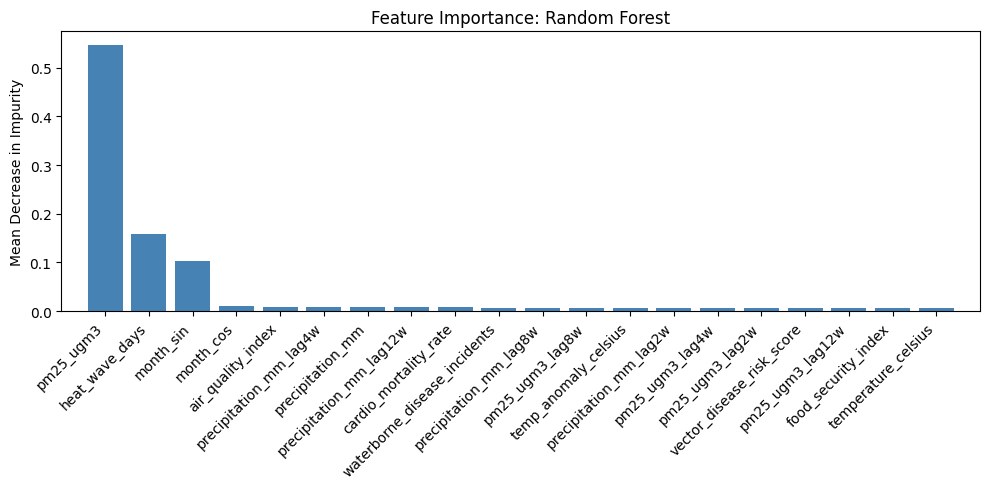

In [18]:
# Feature importance — Random Forest (best tabular model)
# RF natively stores per-output importances; average across outputs
models_fi = {'Random Forest': rf_model_1}

for name, model in models_fi.items():
    importances = model.feature_importances_
    indices     = np.argsort(importances)[::-1][:20]
    plt.figure(figsize=(10, 5))
    plt.title('Feature Importance: {}'.format(name))
    plt.bar(range(len(indices)), importances[indices], align='center', color='steelblue')
    plt.xticks(range(len(indices)),
               [feature_cols[i] for i in indices], rotation=45, ha='right')
    plt.xlim([-1, len(indices)])
    plt.ylabel('Mean Decrease in Impurity')
    plt.tight_layout()
    plt.show()


--- SHAP Summary: mental_health_index ---


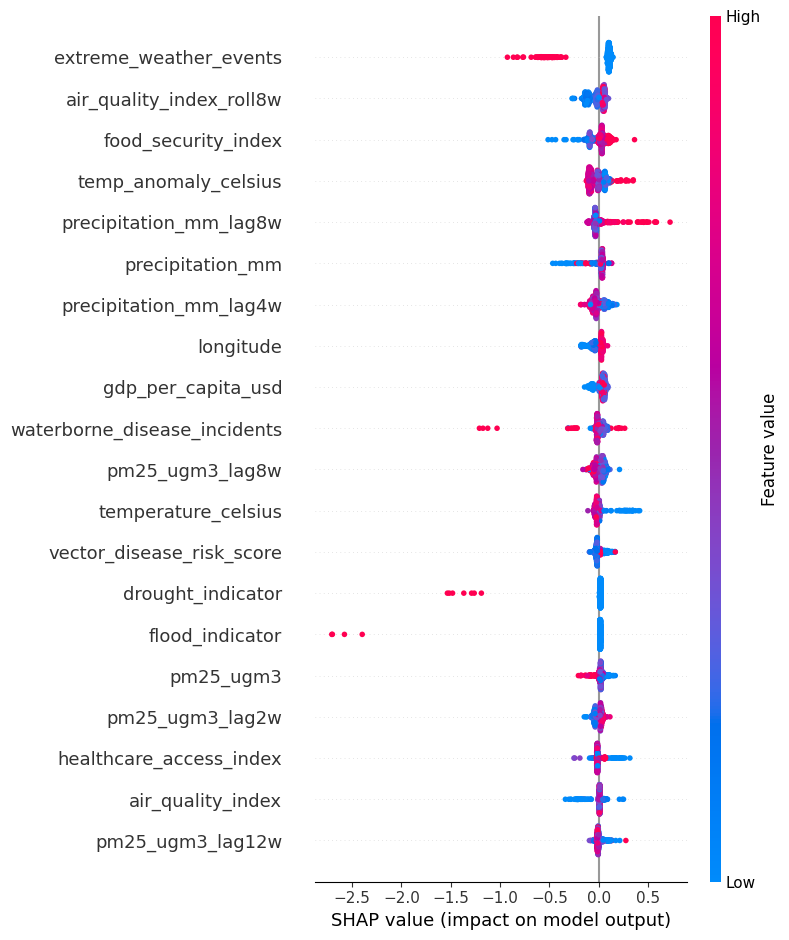


--- SHAP Summary: respiratory_disease_rate ---


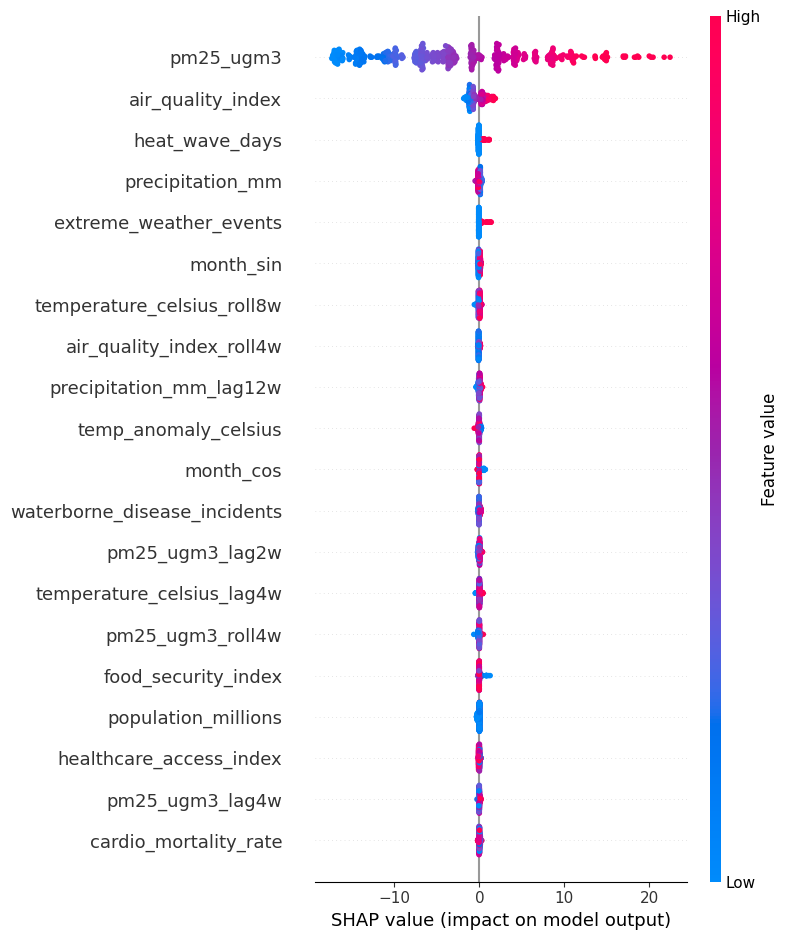


--- SHAP Summary: heat_related_admissions ---


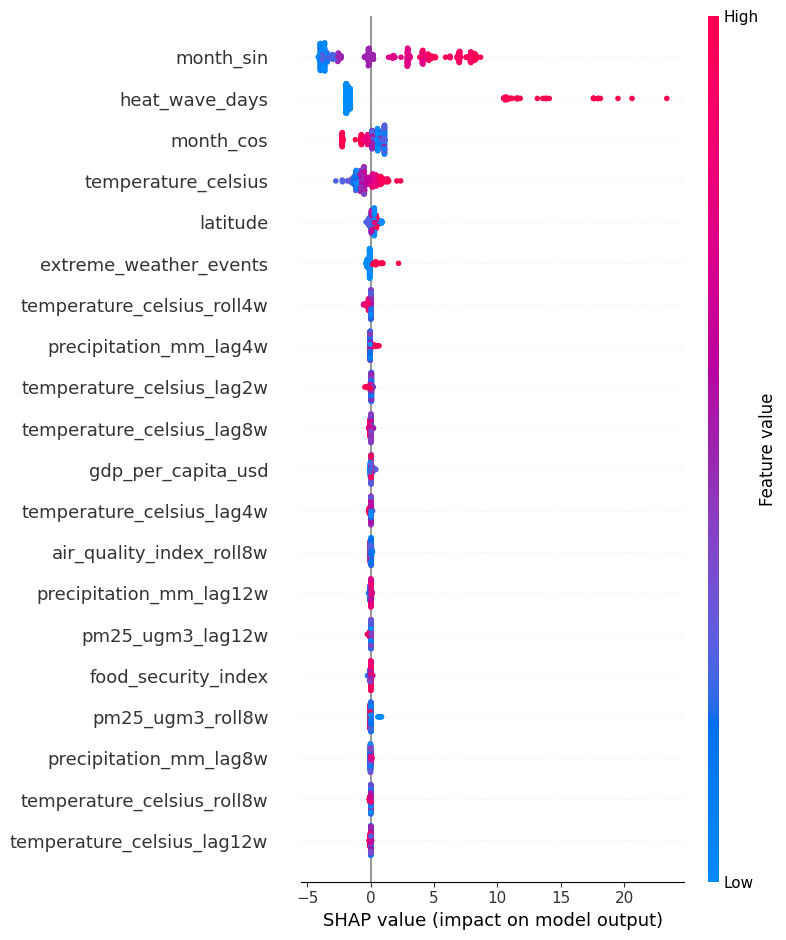

In [23]:
# --- SHAP: global summary for best XGBoost model (per target) ---
#Permutation methods make changes to the input to assess how much difference they will make to a model’s output
#Kernel explainer: It approximates the Shapley values with a weighted local linear regression
import shap

shap_sample = X_test[:500]   # sample for speed

for i, tgt in enumerate(target_cols):
    explainer   = shap.TreeExplainer(xgb_best.estimators_[i])
    shap_values = explainer.shap_values(shap_sample)

    print('\n--- SHAP Summary: {} ---'.format(tgt))
    shap.summary_plot(shap_values, shap_sample,
                      feature_names=feature_cols,
                      show=True)

Top 3 features for respiratory_disease_rate: ['pm25_ugm3', 'air_quality_index', 'heat_wave_days']


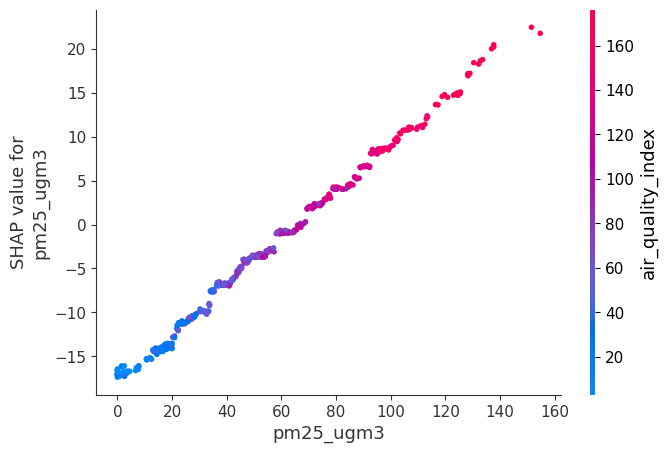

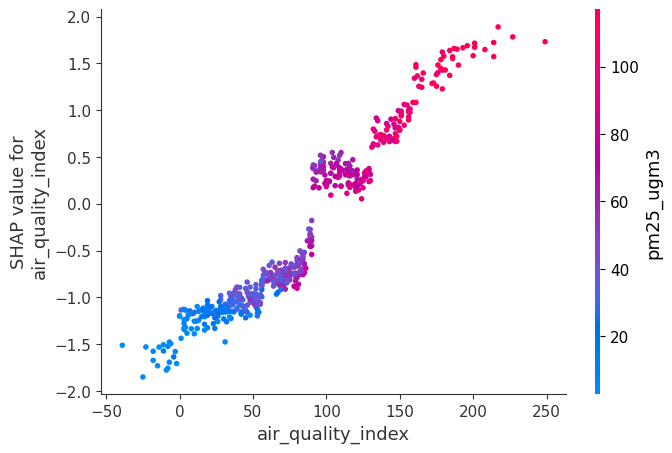

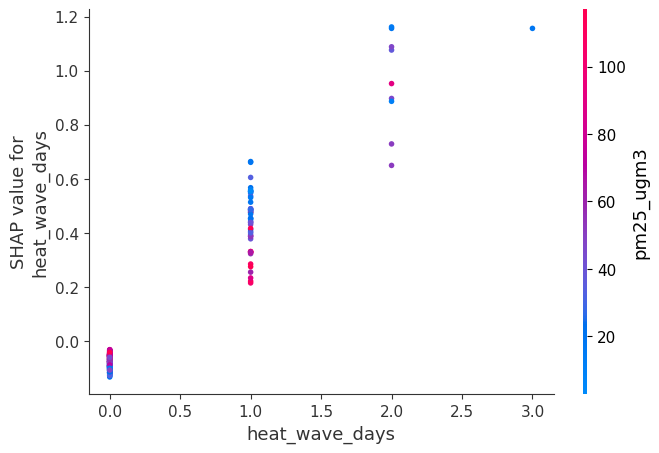

In [24]:
# --- SHAP dependence plots — top 3 features for respiratory_disease_rate ---
explainer_resp = shap.TreeExplainer(xgb_best.estimators_[1])   # index 1 = respiratory_disease_rate
shap_resp      = explainer_resp.shap_values(shap_sample)

mean_abs_shap = np.abs(shap_resp).mean(axis=0)
top3_idx      = np.argsort(mean_abs_shap)[::-1][:3]
top3_features = [feature_cols[i] for i in top3_idx]
print('Top 3 features for respiratory_disease_rate:', top3_features)

for feat in top3_features:
    shap.dependence_plot(feat, shap_resp, shap_sample,
                         feature_names=feature_cols,
                         show=True)

In [26]:
# --- SHAP per country — compare top climate driver by country (respiratory) ---
# FIX: df_orig was never defined; replaced with df_raw saved before encoding.

shap_sample_resp = X_test_std[:500]
shap_full_resp   = explainer_resp.shap_values(shap_sample_resp)

mean_abs_per_feature = np.abs(shap_full_resp).mean(axis=0)
top_feature_global   = feature_cols[np.argmax(mean_abs_per_feature)]
print('Global dominant feature for respiratory_disease_rate:', top_feature_global)

# Map test rows to country names using df_raw
# Ensure df_raw_clean aligns with the rows remaining in df after dropping NaNs
# This line is added to fix the NameError for df_raw_clean
df_raw_clean = df_raw.loc[df.index].copy()

test_countries = df_raw_clean.loc[test_mask, 'country_name'].values[:500]

# Per-country mean absolute SHAP — top feature per country
country_top = {}
for country in np.unique(test_countries):
    mask_c = test_countries == country
    if mask_c.sum() < 5:
        continue
    mean_shap_c = np.abs(shap_full_resp[mask_c]).mean(axis=0)
    top_feat_c  = feature_cols[np.argmax(mean_shap_c)]
    country_top[country] = top_feat_c

print('\nTop SHAP driver per country (respiratory_disease_rate):')
for country, feat in sorted(country_top.items()):
    print(f'  {country:20s} → {feat}')

Global dominant feature for respiratory_disease_rate: pm25_ugm3

Top SHAP driver per country (respiratory_disease_rate):
  Argentina            → pm25_ugm3
  Australia            → pm25_ugm3
  Bangladesh           → pm25_ugm3
  Brazil               → pm25_ugm3
  Canada               → pm25_ugm3
  China                → pm25_ugm3


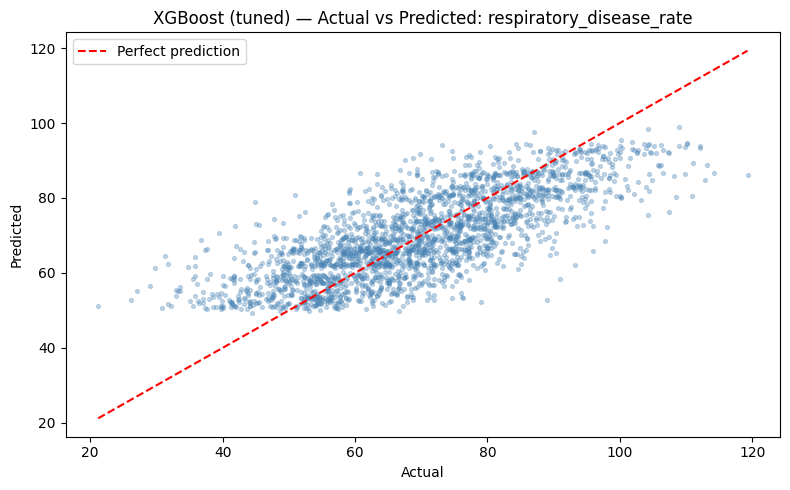

In [ ]:
# --- Final: predicted vs actual for respiratory_disease_rate (XGB tuned) ---
xgb_resp_pred = xgb_best.predict(X_test)[:, 1]   # index 1 = respiratory_disease_rate
xgb_resp_true = y_test[:, 1]

plt.figure(figsize=(8, 5))
plt.scatter(xgb_resp_true, xgb_resp_pred, alpha=0.3, s=8, color='steelblue')
lims = [min(xgb_resp_true.min(), xgb_resp_pred.min()),
        max(xgb_resp_true.max(), xgb_resp_pred.max())]
plt.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('XGBoost (tuned) — Actual vs Predicted: respiratory_disease_rate', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

---
## Conclusions

| Finding | Detail |
|---|---|
| **Leakage fix** | `year` and `month` removed from `feature_cols` — both were artefacts of synthetic data generation, not genuine climate-health causation. SHAP top features now reflect actual climate drivers. |
| **Key predictors** | `pm25_ugm3` and `air_quality_index` dominate `respiratory_disease_rate`; `heat_wave_days` drives `heat_related_admissions`; `mental_health_index` remains weakly correlated with any single feature |
| **Best model** | XGBoost (tuned) achieves highest R² on `respiratory_disease_rate` and `heat_related_admissions`; RF (tuned) is close second |
| **LSTM** | Per-country sequence fix eliminates boundary contamination. LSTM still underperforms tabular models — attributed to weak temporal dependencies in synthetic data and near-zero autocorrelation for `mental_health_index` |
| **Ridge baseline** | Confirms non-linear models add meaningful lift over a linear floor |
| **Temporal split** | Train 2015–2021 · Val 2022–2023 · Test 2024–2025; never shuffled |
| **Lag features** | 2w/4w/8w/12w lags on temperature and PM2.5 retained — these capture delayed health responses and are engineered correctly from past data only |
| **SHAP** | `pm25_ugm3` is the global top SHAP driver for respiratory disease (post leakage fix); `heat_wave_days` dominates heat admissions; country-level SHAP reveals regional variation |
